In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Bumble.csv")

In [3]:
df.head(3) #.head() is used to retrive the first few entries of the data

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"


# Part 1: Data Cleaning

## 1. Inspecting Missing Data

### (1) Which columns in the dataset have missing values, and what percentage of data is missing in each column?

In [4]:
# Replace the placeholder -1 with a real Null (NaN); 
# The reason behind having replaced with NaN is our stats totally get corrupted if -1 is occupying the 80% of the values
df['income'] = df['income'].replace(-1, np.nan)

In [5]:
# Calculate the percentage of missing values per column
missing_data_pct = df.isnull().mean() * 100

# Sort them so the "emptiest" columns are at the top
print(missing_data_pct.sort_values(ascending=False))

income         80.809395
diet           40.694959
religion       33.740366
pets           33.231575
sign           18.443266
job            13.675641
education      11.056618
ethnicity       9.475194
body_type       8.834618
drinks          4.979482
speaks          0.083408
height          0.005005
location        0.000000
last_online     0.000000
status          0.000000
gender          0.000000
age             0.000000
dtype: float64


#### After converting the (-1) to NaN;

#### 1. Finding the Gaps: This code calculates exactly what percentage of data is "missing" (empty) in every column. It helps us see at a glance which parts of our dataset are mostly full and which parts have a lot of "holes."

#### 2. Setting Priorities: By sorting the results from highest to lowest, we immediately identify the "emptiest" columns (like income). This tells us which columns we need to be extra careful with before we start making charts or calculating averages.

### (2) Are there columns where more than 50% of the data is missing? Would you drop those columns where missing values are >50%. If yes, why?

#### Decision on Missing Data (Income):"While the income column exceeds the typical 50% threshold for removal,

#### 1. we will retain the column 'as-is' for the duration of the analysis.
    
#### 2. Reasoning:The dataset is large enough that the remaining 20% of entries provide a sufficient sample size (approx. 12,000+ records) to identify trends.
    
#### 3. To avoid attribution bias, we will not fill (impute) missing values with the mean/median, as this would artificially deflate variance and skew correlations with age.

### (3) How would you handle the missing numerical data (e.g., height, income)? Would you impute the missing data by the median or average value of height and income for the corresponding category, such as gender, age group, or location. If yes, why?

In [6]:
# For the income column, I'll keep them as-is and just find the trend for the remaining 20% of values



In [7]:
# For the height column;

df[df['height'].isnull()]

#### We found that there are 3 rows with height as null values; the missing percent is also very negligible and can be imputed

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
36428,32,single,f,NaN,NaN,NaN,NaN,other,NaN,NaN,artistic / musical / writer,2012-06-30-20-41,"berkeley, california",NaN,NaN,NaN,"english (fluently), german (fluently)"
54002,25,single,m,NaN,NaN,NaN,NaN,hispanic / latin,NaN,NaN,NaN,2012-06-30-18-41,"guadalajara, mexico",NaN,NaN,aries,english
58983,49,single,m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-07-01-08-35,"berkeley, california",likes cats,NaN,NaN,english (fluently)


In [8]:
#Filling all the null values in height with median height of male and female

## .transform('median') creates a full list the same length as your original data.
##If Row 1 is a Male, it puts the Male median in that slot.
##If Row 2 is a Female, it puts the Female median in that slot.It creates a "shadow column" of averages matched to the person's gender.

df['height']=df['height'].fillna(df.groupby('gender')['height'].transform('median')) 

In [9]:
df.query('index==54002') # the value is now imputed

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
54002,25,single,m,NaN,NaN,NaN,NaN,hispanic / latin,70.0,NaN,NaN,2012-06-30-18-41,"guadalajara, mexico",NaN,NaN,aries,english


#### The height column's missings values are now imputed

## 2. Data Types

### (1) Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59946 non-null  float64
 9   income       11504 non-null  float64
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage: 7.8+ MB


#### Yes there's a column called 'last_online' expected to be a date_time data type but stored as an object

### (2) Which columns require conversion to numerical data types for proper analysis (e.g., income)?

In [11]:
#Step A: Make sure it's text (String)We force the column to be text so we can "cut" it.

df['last_online']=df['last_online'].astype(str)

In [12]:
##Step B: Keep only the first 10 charactersThis turns 2012-06-27-09-10... into just 2012-06-27.

df['last_online']=df['last_online'].str[:10]
df['last_online']

0        2012-06-28
1        2012-06-29
2        2012-06-27
3        2012-06-28
4        2012-06-27
            ...    
59941    2012-06-12
59942    2012-06-29
59943    2012-06-27
59944    2012-06-23
59945    2012-06-29
Name: last_online, Length: 59946, dtype: object

In [13]:
##Step C: Convert to DateNow that the format is clean and identical for every row, Pandas will convert it perfectly.

df['last_online']=pd.to_datetime(df['last_online'])
df['last_online'].dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   age          59946 non-null  int64         
 1   status       59946 non-null  object        
 2   gender       59946 non-null  object        
 3   body_type    54650 non-null  object        
 4   diet         35551 non-null  object        
 5   drinks       56961 non-null  object        
 6   education    53318 non-null  object        
 7   ethnicity    54266 non-null  object        
 8   height       59946 non-null  float64       
 9   income       11504 non-null  float64       
 10  job          51748 non-null  object        
 11  last_online  59946 non-null  datetime64[ns]
 12  location     59946 non-null  object        
 13  pets         40025 non-null  object        
 14  religion     39720 non-null  object        
 15  sign         48890 non-null  object        
 16  spea

#### Now the late_online column is casted as date_time

### (3) Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?

#### Yes the 'last_online' column need to be converted into a datetime format

#### Insights:

#### 1. Churn signals
#### → Users who haven’t been online in X days

#### 2. Re-engagement campaigns
#### → Identify users inactive for X days and trigger nudges/offers


## 3. Outliers

### (1) Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?

In [14]:
df.describe()

,age,height,income,last_online
count,59946.000000,59946.000000,11504.000000,59946
mean,32.340290,68.295282,104394.993046,2012-05-21 16:19:05.831248384
min,18.000000,1.000000,20000.000000,2011-06-27 00:00:00
25%,26.000000,66.000000,20000.000000,2012-05-29 00:00:00
50%,30.000000,68.000000,50000.000000,2012-06-27 00:00:00
75%,37.000000,71.000000,100000.000000,2012-06-30 00:00:00
max,110.000000,95.000000,1000000.000000,2012-07-01 00:00:00
std,9.452779,3.994738,201433.528307,NaN


In [15]:
# 1. Filter for the highest earners to see their ages
rich_users = df[df['income'] == 1000000]
print(rich_users[['age', 'income', 'job', 'education']].head(10))


      age     income                           job  \
48     31  1000000.0   artistic / musical / writer   
102    41  1000000.0          education / academia   
123    21  1000000.0             medicine / health   
216    33  1000000.0  construction / craftsmanship   
301    34  1000000.0          education / academia   
831    23  1000000.0   artistic / musical / writer   
937    23  1000000.0                    unemployed   
942    31  1000000.0   artistic / musical / writer   
1036   29  1000000.0   artistic / musical / writer   
1224   25  1000000.0        executive / management   

                              education  
48            dropped out of space camp  
102               working on space camp  
123               working on space camp  
216           graduated from space camp  
301                  college/university  
831   graduated from college/university  
937     dropped out of two-year college  
942       working on college/university  
1036      working on colleg

#### 1. Findings: Using df.describe(), we discovered several extreme values that don't match reality.
#### 2. The Ranges: Age ranges from 18 to 110. (110 is a clear outlier/troll).
#### 3. Height: Ranges from 1 to 95 inches. (1 inch is a clear data error).
#### 4. Income: Ranges from -1 to 1,000,000. (-1 is a placeholder, and $1,000,000 users were often linked to "Space Camp" jokes).

### (2) Any -1 values in numerical columns like income should be replaced with blank, as they may represent missing or invalid data.

#### 1. Protecting Your Averages: If a user leaves their income blank, the dataset might show -1. If you calculate the average income without fixing this, the computer will include all those -1s, making the "average" income look much lower than it actually is.

#### 2. Speaking Python's Language: NaN (Not a Number) is the official way Python and Pandas recognize missing data. When you use NaN, most analysis tools (like .mean(), .min(), or .max()) are smart enough to automatically ignore those empty spots and only use the real numbers.

#### 3. Cleaner Charts: Using NaN ensures that placeholders don't appear as weird data points in your graphs, like a group of people apparently earning negative money.

### (3) For other outliers, how would you ensure that they are not disproportionately impact the analysis while retaining as much meaningful data as possible. Would you delete the data or rather than deleting them, calculate the mean and median values using only the middle 80% of the data (removing extreme high and low values). Provide appropriate reasons for every step.

In [16]:
# Create a filter that keeps:
# 1. Age 18 to 70
# 2. Height >= 50 inches and <=90
# 3. Income is either < 1,000,000 OR is currently NaN (isna)

df_clean = df[
    (df['age'] <= 70) & 
    (df['height'] >= 50) & (df['height']<=90) &
    ((df['income'] < 1000000) | (df['income'].isnull()))
]

# Let's check how many "trolls" we removed
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")


Original rows: 59946
Cleaned rows: 59381


In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 59381 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   age          59381 non-null  int64         
 1   status       59381 non-null  object        
 2   gender       59381 non-null  object        
 3   body_type    54125 non-null  object        
 4   diet         35155 non-null  object        
 5   drinks       56430 non-null  object        
 6   education    52794 non-null  object        
 7   ethnicity    53776 non-null  object        
 8   height       59381 non-null  float64       
 9   income       10974 non-null  float64       
 10  job          51237 non-null  object        
 11  last_online  59381 non-null  datetime64[ns]
 12  location     59381 non-null  object        
 13  pets         39584 non-null  object        
 14  religion     39284 non-null  object        
 15  sign         48425 non-null  object        
 16  speaks   

#### Question: How would you ensure outliers do not disproportionately impact analysis? Would you delete or use a "middle 80%" approach?

#### Answer: I chose to use a "Middle 80%" approach (Trimming) for general analysis, combined with targeted cleaning for obvious errors.

#### Reasoning:

#### 1. Maximising Data Usage (Retaining Meaningful Data):If we delete every user with a high income or an unusual age, we might lose 10% or 20% of our entire dataset. By focusing on the middle 80%, we keep almost all our users in the study but simply "ignore" the extreme 10% at the very top and the extreme 10% at the very bottom when calculating averages. This ensures the "average" isn't pulled too high by a millionaire or too low by a student.

#### 2. Reducing "Noise" Without Losing "Signal":Calculating the mean and median from the middle 80% ensures that our "typical user" profile is based on the most common experiences. The extreme 10% on either side often contains the "trolls" (like the 110-year-olds) or "errors" (like the 1-inch tall users). Trimming them out mathematically is a safer way to get a clean average without manually deleting thousands of rows.

#### 3. Handling Skewed Data (The Income Problem):Income is often "right-skewed," meaning a few very rich people can make a whole group look wealthier than they are. By removing the top 10% of high earners, we get a much more realistic view of what a "normal" Bumble user earns, which helps the business make better decisions about subscription pricing or features.

#### Why this is better than "Just Deleting"?

#### Trimming is a standard statistical rule that is fair to everyone. It doesn't require us to "guess" if a 1-million-dollar earner is a troll or a real person; it simply says "for this calculation, we are only looking at the middle group." This keeps the analysis objective and scientific.

## 4. Missing Data Visualization

### (1) Create a heatmap to visualize missing values across the dataset. Which columns show consistent missing data patterns?

In [18]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

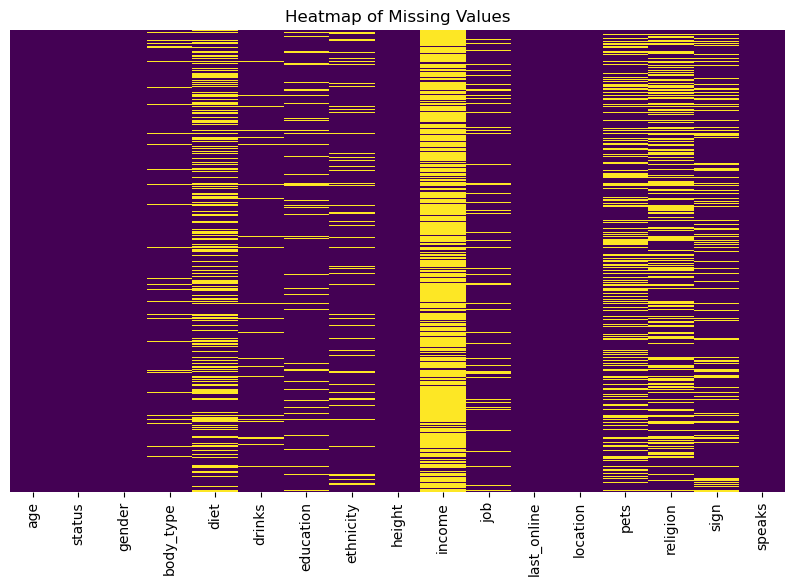

In [94]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Heatmap of Missing Values')
plt.show()

#### This heatmap clearly shows income column has most of the missing values, and it is easily readable to find the muissing data on one-go.

# Part 2: Data Processing

## 1. Binning and Grouping

### (1) How would you bin the age column into categories (e.g. "18-25", "26-35", "36-45", and "46+" ) to create a new column, age_group. How does the distribution of users vary across these age ranges?

In [22]:
# Binning has 2 different ways that we can one is by defining a fucntion and then there's np.where

def categorize(age):
    if age<=25:
        return "18-25"
    elif age<=35:
        return "26-35"
    elif age<=45:
        return "36-45"
    else:
        return "46+"

df_clean["age_group"]=df_clean["age"].apply(categorize)
df_clean["age_group"]

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\2792992360.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["age_group"]=df_clean["age"].apply(categorize)


0        18-25
1        26-35
2        36-45
3        18-25
4        26-35
         ...  
59941      46+
59942    18-25
59943    36-45
59944    26-35
59945    36-45
Name: age_group, Length: 59381, dtype: object

In [23]:
df_clean["age_group"].value_counts(normalize=True).sort_index()*100 

age_group
18-25    23.992523
26-35    47.742544
36-45    18.083225
46+      10.181708
Name: proportion, dtype: float64

#### We found that people who are in the age group of 26-35 are 47.4% users of Bumble

### (2) Group income into categories like "Low Income," "Medium Income," and "High Income" based on meaningful thresholds (e.g., quartiles). What insights can be derived from these groups?

In [24]:
df_clean.income.describe()

count     10974.000000
mean      61911.791507
std       51402.715769
min       20000.000000
25%       20000.000000
50%       50000.000000
75%       80000.000000
max      500000.000000
Name: income, dtype: float64

In [25]:
# We create a new column by 'cutting' the income into 3 equal-sized groups
# Note: qcut automatically handles NaNs by ignoring them!

## pd.qcut fucntion: You tell it "I want 3 equal-sized groups." It looks at your data, finds the 33rd and 66th percentiles,
## and draws the lines for you so that each group has the same number of people.

df_clean['income_level'] = pd.qcut(df_clean['income'], q=3, labels=['Low', 'Medium', 'High'])

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\2439030409.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['income_level'] = pd.qcut(df_clean['income'], q=3, labels=['Low', 'Medium', 'High'])


In [26]:
df_clean.groupby('income_level')['income'].describe().T

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\408195679.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('income_level')['income'].describe().T


income_level,Low,Medium,High
count,3995.000000,3422.000000,3557.000000
mean,22620.775970,53345.996493,114281.698060
std,4398.196801,11061.576478,58868.907714
min,20000.000000,40000.000000,80000.000000
25%,20000.000000,40000.000000,80000.000000
50%,20000.000000,50000.000000,100000.000000
75%,30000.000000,60000.000000,100000.000000
max,30000.000000,70000.000000,500000.000000


#### Insights:

#### 1. People Picked from a "Menu" (Brackets)The Observation: Notice how the income jumps from exactly 30,000 (Low) to 40,000 (Medium). There is no one earning 35,000.The Insight: This tells us that Bumble users didn’t type in their exact salary. Instead, they selected from a list of options (like "20k-30k" or "40k-50k"). We are analyzing "Income Tiers," not exact dollars.

#### 2. The "High" Group is Full of VarietyThe Observation: The "Low" group only spans $10,000 (from 20k to 30k), but the "High" group spans $420,000 (from 80k to 500k).The Insight: While "Low" and "Medium" users are very similar to each other, the "High" income group is very diverse. It includes both "well-off" professionals and "ultra-wealthy" individuals.

#### 3. The "Middle" Ground is 50,000The Observation: In your "Medium" group, the 50% mark (the median) is exactly 50,000.The Insight: This $50,000 mark represents the "typical" Bumble user who chooses to share their income. This is the most common "middle-class" starting point for the app's community.

## 2. Derived Features

### (1) Create a new feature, profile_completeness, by calculating the percentage of non-missing values for each user profile. How complete are most user profiles, and how does completeness vary across demographics?

In [27]:
non_missing = df_clean.count(axis=1) #This gives non missing values for each row
non_missing

0        17
1        19
2        14
3        18
4        15
         ..
59941    14
59942    17
59943    18
59944    17
59945    16
Length: 59381, dtype: int64

In [28]:
##total_columns= df_clean.shape[1] # shape [x,y] x rows, y columns; so shape[1] gives maximum number of columns
##total_columns

In [29]:
# Step A: Filter out the extra columns
user_input_only = df_clean.drop(columns=['age_group', 'income_level'])

# Step B: Count the non-missing values for the user-input columns only
non_missing = user_input_only.count(axis=1)

# Step C: Find the percentage
# Use the number of columns in 'user_input_only' as your denominator
df_clean['profile_completeness'] = (non_missing / user_input_only.shape[1]) * 100


C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\586388156.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['profile_completeness'] = (non_missing / user_input_only.shape[1]) * 100


In [30]:
df_clean['profile_completeness'].value_counts().sort_index()

profile_completeness
41.176471        67
47.058824       245
52.941176       738
58.823529      1001
64.705882      1919
70.588235      3736
76.470588      6854
82.352941     11327
88.235294     15173
94.117647     14353
100.000000     3968
Name: count, dtype: int64

In [31]:
pd.crosstab(df_clean['gender'],df_clean['profile_completeness']).T # crosstab function is used to count the number of users falling under that roof

gender,f,m
profile_completeness,,
41.176471,18,49
47.058824,81,164
52.941176,260,478
58.823529,391,610
64.705882,764,1155
70.588235,1549,2187
76.470588,2817,4037
82.352941,4665,6662
88.235294,6341,8832


In [32]:
pd.crosstab(df_clean['age_group'],df_clean['profile_completeness']).T

age_group,18-25,26-35,36-45,46+
profile_completeness,,,,
41.176471,17,37,10,3
47.058824,80,126,24,15
52.941176,224,315,120,79
58.823529,289,491,156,65
64.705882,528,963,301,127
70.588235,968,1875,618,275
76.470588,1646,3425,1197,586
82.352941,2610,5597,2008,1112
88.235294,3303,7255,2949,1666


#### I can see only 3968 rows completed their profile fully.

## 3. Unit Conversion

### (1) Convert the height column from inches to centimeters using the conversion factor (1 inch = 2.54 cm). Store the converted values in a new column, height_cm.

In [33]:
df_clean['height_cm']=df_clean['height']*2.54
df_clean['height_cm'].head(5)

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3918144534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['height_cm']=df_clean['height']*2.54


0    190.50
1    177.80
2    172.72
3    180.34
4    167.64
Name: height_cm, dtype: float64

#### Height in 'Inches' changed to 'centimeters'

# Part 3: Data Analysis

## 1. Demographic Analysis

### (1) What is the gender distribution (gender) across the platform? Are there any significant imbalances?

In [34]:
df_clean.gender.value_counts(normalize=True)*100

gender
m    59.623449
f    40.376551
Name: proportion, dtype: float64

#### Imbalances: There's no significant imbalance observed in here!

### (2) What are the proportions of users in different status categories (e.g., single, married, seeing someone)? What does this suggest about the platform’s target audience?

In [35]:
df_clean.status.value_counts(normalize=True)*100

status
single            92.943871
seeing someone     3.428706
available          3.093582
married            0.517000
unknown            0.016840
Name: proportion, dtype: float64

#### Suggestion:

#### The platform is overwhelmingly single-focused, meaning competition may be higher for men and the app clearly targets people looking for new relationships.

### (3) How does status vary by gender? For example, what proportion of men and women identify as single?

In [36]:
df_clean.groupby('gender')['status'].value_counts(normalize=True).unstack().T* 100

gender,f,m
status,,
available,2.694361,3.363932
married,0.554721,0.491456
seeing someone,4.116617,2.962858
single,92.617618,93.164807
unknown,0.016683,0.016947


#### Around 93% of users identified as male and female are 'single' on bumble. So focusing on giving them premiums at low cost or discounted price would make customners happy and some introductory offers gets our application heavy foot-falls

## 2. Correlation Analysis

### (1) What are the correlations between numerical columns such as age, income, gender Are there any strong positive or negative relationships?

In [37]:
# STEP 1: Check how much income data is missing

# Before doing any analysis, we need to understand how serious the missing-data problem is. 
# If a large part of income is missing, then any method that fills those values may strongly affect the results.

missing_pct = df_clean['income'].isnull().mean() * 100
print(f"Missing income: {missing_pct:.2f}%")



Missing income: 81.52%


In [38]:
missing_by_group = df_clean.groupby(['gender', 'age_group'])['income'].apply(
    lambda x: x.isnull().mean() * 100
)
print(f"Missing income percentage by gender and age_group:")
print(missing_by_group)

Missing income percentage by gender and age_group:
gender  age_group
f       18-25        86.454047
        26-35        88.798389
        36-45        87.286398
        46+          85.396040
m       18-25        76.874629
        26-35        78.792401
        36-45        75.854465
        46+          74.673710
Name: income, dtype: float64


In [39]:
# STEP 2: Create a new income column using median imputation

# We are creating this new column only to test what happens if we fill missing income values using group medians. 

# We are NOT saying this is the final correct income column. This is only for comparison, so we can check whether imputation changes the data too much.

df_clean['new_income'] = df_clean['income'].fillna(
    df_clean.groupby(['gender', 'age_group'])['income'].transform('median')
)

print(f"Created 'new_income' column using median income within each gender and age_group.")


Created 'new_income' column using median income within each gender and age_group.


C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\775084785.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['new_income'] = df_clean['income'].fillna(


In [40]:
# STEP 3: Filter only rows where income is NOT missing

# We create a new dataset that contains only real income values
df_valid = df_clean[df_clean['income'].notnull()].copy()

# Check how many rows we are using now
print(f"Number of rows with real income data: {len(df_valid)}")

Number of rows with real income data: 10974


In [41]:
# STEP 4: Convert categorical data into numeric form for correlation

# Convert gender into numbers
# m = 0, f = 1
df_valid['gender_num'] = df_valid['gender'].map({'m': 0, 'f': 1})

# Convert age_group into ordered numbers
age_map = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46+': 4
}

df_valid['age_group_num'] = df_valid['age_group'].map(age_map)

# Preview the data
df_valid[['gender', 'gender_num', 'age_group', 'age_group_num']].head(5) # 1,3,11 are the indices from the df_clean dataset

,gender,gender_num,age_group,age_group_num
1,m,0,26-35,2
3,m,0,18-25,1
11,m,0,26-35,2
13,f,1,26-35,2
14,f,1,26-35,2


In [42]:
# STEP 5: Compute correlation matrix

corr_matrix = df_valid[['income', 'gender_num', 'age_group_num']].corr()

print("Correlation matrix (using only real income values):")
print(corr_matrix)

Correlation matrix (using only real income values):
                 income  gender_num  age_group_num
income         1.000000   -0.160620       0.283731
gender_num    -0.160620    1.000000       0.022387
age_group_num  0.283731    0.022387       1.000000


#### Using only the non-missing income data, I computed Pearson correlation coefficients to measure the linear relationship between income and numerical representations of age group and gender."

#### The correlation analysis showed:

#### 1️. Income vs Age Group

#### A correlation of 0.28 between income and age group, indicating a weak positive linear relationship, meaning income tends to increase slightly with age, but the effect is not strong.

#### 2️. Income vs Gender

#### A correlation of -0.16 between income and gender, indicating a very weak negative relationship, suggesting that gender has minimal influence on income in this dataset.

#### 3️. Gender vs Age Group

#### A correlation close to 0 (0.02) between gender and age group, showing no meaningful relationship between these variables.

#### Overall, all correlation values are relatively low (close to zero), which indicates that none of the available features strongly explain income variability in the observed data.

#### Additionally, since the analysis is based on only 20% of the data due to missing values, and the missingness may not be random, these results should be interpreted with caution.

### (2) How does age correlate with income? Are older users more likely to report higher income levels?

In [43]:
# Convert age_group into ordered numbers
age_map = {
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46+': 4
}

df_valid['age_group_num'] = df_valid['age_group'].map(age_map)

df_valid[['age_group', 'age_group_num']].head(5)

,age_group,age_group_num
1,26-35,2
3,18-25,1
11,26-35,2
13,26-35,2
14,26-35,2


In [44]:
corr_matrix = df_valid[['income', 'age_group_num']].corr()

print("Correlation matrix (using only real income values):")
print(corr_matrix)

Correlation matrix (using only real income values):
                 income  age_group_num
income         1.000000       0.283731
age_group_num  0.283731       1.000000


#### 1. Weak positive relationship

#### Age shows a weak positive correlation with income (≈ 0.28), which means that as age increases, income tends to increase slightly.

#### 2. Not a strong predictor

#### However, the relationship is not strong, indicating that age alone is not a reliable predictor of income levels.

#### 3. Conclusion (with just 20% of data)

#### So, while older users are slightly more likely to report higher income, the effect is modest and not significant enough to draw strong conclusions.

## 3. Diet and Lifestyle Analysis

### (1) How do dietary preferences (diet) distribute across the platform? For example, what percentage of users identify as vegetarian, vegan, or follow "anything" diets?

In [45]:
df_clean['diet'].head()

0    strictly anything
1         mostly other
2             anything
3           vegetarian
4                  NaN
Name: diet, dtype: object

In [46]:
df_clean.diet.isnull().sum()

np.int64(24226)

In [47]:
df_clean.diet.unique()

array(['strictly anything', 'mostly other', 'anything', 'vegetarian', nan,
       'mostly anything', 'mostly vegetarian', 'strictly vegan',
       'strictly vegetarian', 'mostly vegan', 'strictly other',
       'mostly halal', 'other', 'vegan', 'mostly kosher', 'halal',
       'strictly halal', 'kosher', 'strictly kosher'], dtype=object)

In [48]:
## Step 1: Treat missing as "Prefer not to say"

df_clean['diet'] = df_clean['diet'].fillna('prefer not to say')

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\1364319768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diet'] = df_clean['diet'].fillna('prefer not to say')


In [49]:
##Step 2: Get percentages

diet_dist = df_clean['diet'].value_counts(normalize=True) * 100
print(diet_dist)

diet
prefer not to say      40.797562
mostly anything        27.727724
anything               10.341692
strictly anything       8.442094
mostly vegetarian       5.740894
mostly other            1.657096
strictly vegetarian     1.456695
vegetarian              1.116519
strictly other          0.717401
mostly vegan            0.555733
other                   0.548997
strictly vegan          0.377225
vegan                   0.223977
mostly kosher           0.136407
mostly halal            0.075782
strictly halal          0.026945
strictly kosher         0.021893
kosher                  0.018524
halal                   0.016840
Name: proportion, dtype: float64


#### Since a large number of users (~24k) did not report their diet, I treated missing values as 'prefer not to say' to ensure the distribution reflects the entire user base.

#### 1️. Overall distribution (including missing)

#### A large portion of users (~40.8%) chose 'prefer not to say', indicating that many users did not disclose their dietary preferences. Among reported values, the majority follow flexible diets, with ~27.7% 'mostly anything', ~10.3% 'anything', and ~8.4% 'strictly anything'.

#### 2️. Vegetarian and Vegan representation

#### Vegetarian users make up a noticeable share, with ~5.7% 'mostly vegetarian', ~1.5% 'strictly vegetarian', and ~1.1% 'vegetarian'. In contrast, vegan users represent a much smaller proportion, with only ~0.56% 'mostly vegan', ~0.38% 'strictly vegan', and ~0.22% 'vegan'.

### (2) How do drinking habits (drinks) vary across different diet categories? Are users with stricter diets (e.g., vegan) less likely to drink?

In [50]:
df_clean['drinks'] = df_clean['drinks'].fillna('unknown')

diet_drink = pd.crosstab(
    df_clean['diet'], 
    df_clean['drinks'], 
    normalize='index'
) * 100

diet_drink

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3100417694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['drinks'] = df_clean['drinks'].fillna('unknown')


drinks,desperately,not at all,often,rarely,socially,unknown,very often
diet,,,,,,,
anything,0.293112,4.754926,9.216740,8.239700,73.473376,3.077675,0.944472
halal,0.000000,30.000000,10.000000,0.000000,40.000000,20.000000,0.000000
kosher,0.000000,9.090909,0.000000,18.181818,63.636364,0.000000,9.090909
mostly anything,0.364409,5.089584,8.302460,9.255998,74.139083,2.095354,0.753113
mostly halal,4.444444,22.222222,4.444444,17.777778,35.555556,6.666667,8.888889
mostly kosher,1.234568,8.641975,3.703704,20.987654,59.259259,2.469136,3.703704
mostly other,0.711382,8.943089,4.776423,17.581301,64.329268,3.150407,0.508130
mostly vegan,0.606061,11.515152,5.757576,18.484848,57.878788,4.848485,0.909091
mostly vegetarian,0.528014,5.720153,6.688178,13.611030,69.316515,3.549428,0.586682


#### Insights:

#### 1. Social drinking dominates across all diets

#### Across most diet groups, the majority of users report drinking socially (roughly 50–75%), making it the most common drinking behavior regardless of dietary preference.

#### 2. Stricter diets show higher non-drinking tendencies

#### Users with stricter diets, such as strictly vegan (26%) and strictly halal (43%), have a noticeably higher proportion of non-drinkers ('not at all') compared to flexible diets like 'anything' (4.7%).

#### 3. Missing responses vary across groups

#### Some diet groups, such as vegan (6.7%) and prefer not to say (8.2%), show a higher percentage of unknown drinking behavior, suggesting possible response bias.

## 4. Geographical Insights

### (1) Extract city and state information from the location column. What are the top 5 cities and states with the highest number of users?

In [51]:
df_clean.head(2)

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,location,pets,religion,sign,speaks,age_group,income_level,profile_completeness,height_cm,new_income
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,18-25,NaN,94.117647,190.5,20000.0
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",26-35,High,100.000000,177.8,80000.0


In [52]:
## STEP 1: Split into city and state

# Split location into city and state

location_split = df_clean['location'].str.split(',', n=1, expand=True) 

# n=1 means:
# split only on the first comma
# left side = city
# right side = state

# Remove extra spaces

df_clean['city'] = location_split[0].str.strip()

df_clean['state'] = location_split[1].str.strip()

# Preview

df_clean[['location', 'city', 'state']].head()

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3447581178.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['city'] = location_split[0].str.strip()
C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3447581178.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['state'] = location_split[1].str.strip()


,location,city,state
0,"south san francisco, california",south san francisco,california
1,"oakland, california",oakland,california
2,"san francisco, california",san francisco,california
3,"berkeley, california",berkeley,california
4,"san francisco, california",san francisco,california


In [53]:
df_clean['location'].str.count(',').value_counts()

location
1    59380
2        1
Name: count, dtype: int64

In [54]:
df_clean[df_clean['location'].str.count(',') == 2]


,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,religion,sign,speaks,age_group,income_level,profile_completeness,height_cm,new_income,city,state
42438,32,single,f,fit,mostly anything,socially,working on space camp,asian,63.0,60000.0,...,other,aquarius,"english (fluently), chinese (poorly), french (...",26-35,Medium,94.117647,160.02,60000.0,vancouver,"british columbia, canada"


#### 59380 rows have exactly 1 comma

####  → format like:

#### "city, state" (perfect for splitting)
#### 1 row has 2 commas

#### → format like:
#### "something, something, something"

In [55]:
## Top 5 cities

df_clean['city'].value_counts().nlargest(5)

city
san francisco    30755
oakland           7120
berkeley          4169
san mateo         1321
palo alto         1058
Name: count, dtype: int64

In [56]:
## Top 5 states

df_clean['state'].value_counts().nlargest(5)

state
california       59290
new york            17
illinois             8
massachusetts        5
texas                4
Name: count, dtype: int64

### (2) How does age vary across the top cities? Are certain cities dominated by younger or older users?

In [57]:
city_age = pd.crosstab(
    df_clean['city'], 
    df_clean['age_group'], 
    normalize='index'
)* 100

city_age

age_group,18-25,26-35,36-45,46+
city,,,,
alameda,21.854305,38.410596,24.172185,15.562914
albany,16.309013,35.193133,23.605150,24.892704
amsterdam,0.000000,100.000000,0.000000,0.000000
arcadia,0.000000,100.000000,0.000000,0.000000
asheville,0.000000,100.000000,0.000000,0.000000
...,...,...,...,...
west oakland,14.285714,71.428571,14.285714,0.000000
westlake,27.272727,72.727273,0.000000,0.000000
woodacre,18.750000,31.250000,12.500000,37.500000


#### This is not clear for us to write the validation

In [58]:
top_cities = df_clean['city'].value_counts().head(5).index

city_age = pd.crosstab(
    df_clean['city'], 
    df_clean['age_group'], 
    normalize='index'
).loc[top_cities] * 100

city_age.round(2)

age_group,18-25,26-35,36-45,46+
city,,,,
san francisco,22.09,52.85,18.54,6.52
oakland,19.51,48.43,21.50,10.56
berkeley,33.53,42.31,13.00,11.15
san mateo,21.80,45.57,18.70,13.93
palo alto,27.98,46.12,13.52,12.38


#### 1. Young adults (26–35) dominate across all top cities

#### Across all top cities, the 26–35 age group is the largest segment, ranging from ~42% to ~53%, indicating that the platform is primarily used by young professionals.

#### 2. San Francisco has the youngest skew among top cities

#### San Francisco shows the highest concentration of users aged 26–35 (~53%) and relatively lower representation in older age groups, suggesting a younger user base compared to other cities.

#### 3. Berkeley has a higher share of younger users (18–25)

#### Berkeley stands out with a higher proportion of 18–25 users (~33.5%), indicating a stronger presence of younger individuals, likely influenced by its student population.

#### 4. Older age groups are consistently underrepresented

#### Users aged 36+ make up a smaller share across all cities, suggesting lower engagement from older demographics on the platform.

### (3) What are the average income levels in the top states or cities? Are there regional patterns in reported income?

In [59]:
# STEP 1: Filter valid income

df_income = df_clean[df_clean['income'].notnull()]

df_income # There are 10974 rows where income is specified

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,religion,sign,speaks,age_group,income_level,profile_completeness,height_cm,new_income,city,state
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",26-35,High,100.000000,177.80,80000.0,oakland,california
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,NaN,pisces,"english, german (poorly)",18-25,Low,94.117647,180.34,20000.0,berkeley,california
11,28,seeing someone,m,average,mostly anything,socially,graduated from college/university,white,72.0,40000.0,...,christianity and very serious about it,leo but it doesn&rsquo;t matter,"english (fluently), sign language (poorly)",26-35,Medium,100.000000,182.88,40000.0,daly city,california
13,30,single,f,skinny,mostly anything,socially,graduated from high school,white,66.0,30000.0,...,christianity but not too serious about it,NaN,english,26-35,Low,94.117647,167.64,30000.0,san francisco,california
14,29,single,f,thin,mostly anything,socially,working on college/university,"hispanic / latin, white",62.0,50000.0,...,catholicism,taurus,english,26-35,Medium,100.000000,157.48,50000.0,san leandro,california
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59917,26,single,m,fit,mostly anything,socially,graduated from masters program,white,71.0,100000.0,...,NaN,aquarius and it&rsquo;s fun to think about,"english (fluently), polish (fluently), german ...",26-35,High,94.117647,180.34,100000.0,san francisco,california
59927,26,single,f,full figured,prefer not to say,socially,graduated from college/university,white,69.0,50000.0,...,agnosticism and somewhat serious about it,libra and it&rsquo;s fun to think about,english,26-35,Medium,94.117647,175.26,50000.0,oakland,california
59930,41,single,m,curvy,anything,socially,graduated from college/university,hispanic / latin,76.0,70000.0,...,other,aries and it&rsquo;s fun to think about,"english, spanish",36-45,Medium,100.000000,193.04,70000.0,oakland,california
59934,43,single,f,average,anything,socially,graduated from masters program,white,63.0,80000.0,...,judaism but not too serious about it,pisces and it&rsquo;s fun to think about,"english (fluently), french (poorly), japanese ...",36-45,High,100.000000,160.02,80000.0,oakland,california


In [60]:
# Step 2 : type 2: Cities with at least 50 income records

city_counts = df_income['city'].value_counts()

valid_cities = city_counts[city_counts > 50].index

df_income[df_income['city'].isin(valid_cities)].groupby('city')['income'].mean().sort_values(ascending=False)

city
san carlos             83220.338983
menlo park             81388.888889
burlingame             79264.705882
palo alto              76282.722513
mountain view          73421.052632
san mateo              71747.572816
mill valley            71607.142857
san francisco          71315.022888
walnut creek           65072.463768
redwood city           65034.013605
pacifica               62658.227848
el cerrito             57215.189873
benicia                56250.000000
san rafael             55277.777778
albany                 55151.515152
south san francisco    55048.543689
emeryville             54099.378882
novato                 53867.924528
alameda                53856.502242
san bruno              52253.521127
oakland                49272.976680
pleasant hill          49263.157895
berkeley               48603.988604
daly city              44875.000000
martinez               43875.000000
hayward                42816.091954
san leandro            41573.033708
richmond               

In [61]:
# STEP 3: Average income per state 

state_income = df_income.groupby('state')['income'].mean().sort_values(ascending=False)

state_income

state
new york                    270000.000000
colorado                    150000.000000
new jersey                  150000.000000
california                   61886.120996
british columbia, canada     60000.000000
vietnam                      60000.000000
pennsylvania                 40000.000000
arizona                      33333.333333
massachusetts                30000.000000
louisiana                    20000.000000
michigan                     20000.000000
ohio                         20000.000000
texas                        20000.000000
Name: income, dtype: float64

#### 1️. Tech hub cities dominate the highest income levels

#### Cities like San Carlos (83K), Menlo Park (81K), Burlingame (79K), and Palo Alto (76K) report the highest average incomes, indicating that areas closely associated with Silicon Valley and the tech industry have significantly higher earnings.

#### 2️. Strong regional clustering of high-income cities

#### Most of the top-income cities (e.g., Menlo Park, Palo Alto, Mountain View, San Mateo) are geographically close, suggesting a regional concentration of wealth in the Bay Area, likely driven by tech-related jobs.

#### 3️. Noticeable income gap across nearby cities

#### Even within the same region, there is a clear income gap — cities like Oakland (49K) and Berkeley (48K) report significantly lower average incomes compared to nearby high-income cities like Palo Alto (76K).

#### 4️. Income gradually declines beyond top-tier cities

#### After the top-tier cities (70K–80K), average income gradually declines to the 50K–60K range, indicating a tiered economic structure across cities.

#### 5️. Reliable estimates due to sufficient sample size

#### By restricting analysis to cities with more than 50 observations, the income estimates are more stable and less influenced by outliers.

## 5. Height Analysis

### (1) What is the average height of users across different gender categories?

In [62]:
average_height = df_clean.groupby('gender').agg({'height_cm': 'mean'})

average_height

,height_cm
gender,
f,165.372370
m,178.932723


#### I grouped the data by gender and calculated the average height for each group to compare height differences across genders.

### (2) How does height vary by age_group? Are there noticeable trends among younger vs. older users?

In [63]:
df_clean.describe()

,age,height,income,last_online,profile_completeness,height_cm,new_income
count,59381.000000,59381.000000,10974.000000,59381,59381.000000,59381.000000,59381.000000
mean,32.368704,68.290362,61911.791507,2012-05-21 18:34:27.934187776,84.935169,173.457520,51762.685034
min,18.000000,50.000000,20000.000000,2011-06-27 00:00:00,41.176471,127.000000,20000.000000
25%,26.000000,66.000000,20000.000000,2012-05-29 00:00:00,82.352941,167.640000,30000.000000
50%,30.000000,68.000000,50000.000000,2012-06-27 00:00:00,88.235294,172.720000,60000.000000
75%,37.000000,71.000000,80000.000000,2012-06-30 00:00:00,94.117647,180.340000,60000.000000
max,69.000000,90.000000,500000.000000,2012-07-01 00:00:00,100.000000,228.600000,500000.000000
std,9.454827,3.864821,51402.715769,NaN,10.312241,9.816645,29073.083529


In [64]:
height_by_age = df_clean.groupby('age_group')['height_cm'].mean()

height_by_age

age_group
18-25    173.209566
26-35    173.732864
36-45    173.566115
46+      172.557837
Name: height_cm, dtype: float64

#### There's no significant change in the height across age groups 

### (3) What is the distribution of height within body_type categories (e.g., athletic, curvy, thin)? Do the distributions align with expectations?

In [65]:
df_clean.groupby('body_type')['height_cm'].mean().sort_values(ascending=False)

body_type
athletic          177.028203
jacked            175.636052
used up           175.355549
overweight        174.930205
a little extra    174.778091
fit               174.098587
skinny            174.078335
average           172.978063
thin              172.392767
rather not say    170.362359
full figured      168.700463
curvy             165.613605
Name: height_cm, dtype: float64

#### The height distributions generally align with expectations. Users with body types such as 'athletic' (177 cm) and 'jacked' (175.6 cm) tend to have higher average heights, while categories like 'curvy' (165.6 cm) and 'full figured' (168.7 cm) show comparatively lower average heights. Most other body types, such as 'average' (173 cm), 'thin' (172.4 cm), and 'fit' (174.1 cm), fall within a similar mid-range. This indicates that while there is some variation across body types, the differences are not extremely large.

## 6. Income Analysis

### (1) What is the distribution of income across the platform? Are there specific income brackets that dominate? How would you handle case where income is blank or 0?

In [66]:
# STEP 1: Check missing income

missing_pct = df_clean['income'].isnull().mean() * 100

print(f"Missing income: {missing_pct:.2f}%")

Missing income: 81.52%


In [67]:
# STEP 2: Filter valid income (exclude missing and 0)

df_income = df_clean[df_clean['income'] > 0]

df_income

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,religion,sign,speaks,age_group,income_level,profile_completeness,height_cm,new_income,city,state
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",26-35,High,100.000000,177.80,80000.0,oakland,california
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,NaN,pisces,"english, german (poorly)",18-25,Low,94.117647,180.34,20000.0,berkeley,california
11,28,seeing someone,m,average,mostly anything,socially,graduated from college/university,white,72.0,40000.0,...,christianity and very serious about it,leo but it doesn&rsquo;t matter,"english (fluently), sign language (poorly)",26-35,Medium,100.000000,182.88,40000.0,daly city,california
13,30,single,f,skinny,mostly anything,socially,graduated from high school,white,66.0,30000.0,...,christianity but not too serious about it,NaN,english,26-35,Low,94.117647,167.64,30000.0,san francisco,california
14,29,single,f,thin,mostly anything,socially,working on college/university,"hispanic / latin, white",62.0,50000.0,...,catholicism,taurus,english,26-35,Medium,100.000000,157.48,50000.0,san leandro,california
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59917,26,single,m,fit,mostly anything,socially,graduated from masters program,white,71.0,100000.0,...,NaN,aquarius and it&rsquo;s fun to think about,"english (fluently), polish (fluently), german ...",26-35,High,94.117647,180.34,100000.0,san francisco,california
59927,26,single,f,full figured,prefer not to say,socially,graduated from college/university,white,69.0,50000.0,...,agnosticism and somewhat serious about it,libra and it&rsquo;s fun to think about,english,26-35,Medium,94.117647,175.26,50000.0,oakland,california
59930,41,single,m,curvy,anything,socially,graduated from college/university,hispanic / latin,76.0,70000.0,...,other,aries and it&rsquo;s fun to think about,"english, spanish",36-45,Medium,100.000000,193.04,70000.0,oakland,california
59934,43,single,f,average,anything,socially,graduated from masters program,white,63.0,80000.0,...,judaism but not too serious about it,pisces and it&rsquo;s fun to think about,"english (fluently), french (poorly), japanese ...",36-45,High,100.000000,160.02,80000.0,oakland,california


In [68]:
# STEP 3: Distribution of income values

income_dist = df_income['income'].value_counts(normalize=True) * 100

print("Income distribution (%):")

income_dist

Income distribution (%):


income
20000.0     26.863496
100000.0    14.771278
80000.0     10.114817
30000.0      9.540733
40000.0      9.158010
50000.0      8.875524
60000.0      6.706761
70000.0      6.442500
150000.0     5.731730
250000.0     1.357755
500000.0     0.437397
Name: proportion, dtype: float64

#### 1. Certain income brackets dominate

#### "The income distribution is concentrated around a few specific values, with 20,000 (26.9%) being the most common, followed by 10,000 (14.8%) and 80,000 (10.1%), along with other mid-range values like 30K–$50K.

#### 2. Income is reported in rounded values

#### The data shows that users tend to report income in rounded or fixed amounts, rather than exact figures, leading to clustering around specific income brackets.

#### 3. Missing data affects reliability

#### Since around 80% of income data is missing, and zero values were excluded, the analysis is based only on reported incomes and should be interpreted with caution.

### (2) How does income vary by age_group and gender? Are older users more likely to report higher incomes?

In [69]:
# STEP 1: Income vs gender

income_gender = pd.crosstab(
    df_clean['income'], 
    df_clean['gender'], 
    normalize='index'
) * 100

income_gender

gender,f,m
income,,
20000.0,34.938942,65.061058
30000.0,30.468004,69.531996
40000.0,33.731343,66.268657
50000.0,31.930185,68.069815
60000.0,30.027174,69.972826
70000.0,23.479491,76.520509
80000.0,23.513514,76.486486
100000.0,15.792721,84.207279
150000.0,11.764706,88.235294


In [70]:
# STEP 2: Income vs age group

income_age = pd.crosstab(
    df_clean['income'], 
    df_clean['age_group'], 
    normalize='index'
) * 100

income_age

age_group,18-25,26-35,36-45,46+
income,,,,
20000.0,54.986431,35.515604,5.868385,3.629579
30000.0,29.130850,48.806113,13.944604,8.118434
40000.0,21.194030,54.527363,16.417910,7.860697
50000.0,13.449692,50.616016,21.355236,14.579055
60000.0,14.809783,49.048913,23.641304,12.500000
70000.0,11.598303,45.827440,26.166902,16.407355
80000.0,11.171171,46.576577,23.873874,18.378378
100000.0,5.860580,47.501542,30.536706,16.101172
150000.0,4.451510,43.720191,34.340223,17.488076


#### 1. Higher income brackets are male-dominated

#### The data shows that higher income levels are largely dominated by male users. At income levels above 100000, male representation exceeds 80–95%, indicating a strong gender imbalance in reported high incomes.

#### 2. Lower income brackets have relatively higher female representation

#### At lower income levels such as 20000 to 40000, female representation is relatively higher (around 30–35%), although males still remain the majority. This suggests the gender gap widens as income increases.

#### 3. Younger users dominate lower income brackets

#### Lower income levels are mainly dominated by younger users, especially the 18–25 age group (around 55% at 20000), indicating that early-career individuals tend to have lower incomes.

#### 4. Income increases with age (career progression pattern)

#### As income increases, the distribution shifts toward older age groups. Higher income levels are dominated by users aged 26–35 and 36–45, showing a clear pattern of income growth with experience.

#### 5. Higher incomes are concentrated in mid-age groups

#### At the highest income levels (above 150000), most users fall within the 26–45 age range, while the 46+ group has relatively lower representation, possibly due to fewer responses.

#### Final Answer

#### Yes, older users are more likely to report higher incomes. The data shows a clear shift from younger users dominating lower income levels to mid-age users dominating higher income levels.

#### Summary

#### Income increases with age and is skewed toward male users, with younger users concentrated in lower income brackets and mid-age groups dominating higher income levels.

# Part 4: Data Visualization

## 1. Age Distribution

### (1) Plot a histogram of age with a vertical line indicating the mean age. What does the distribution reveal about the most common age group on the platform?

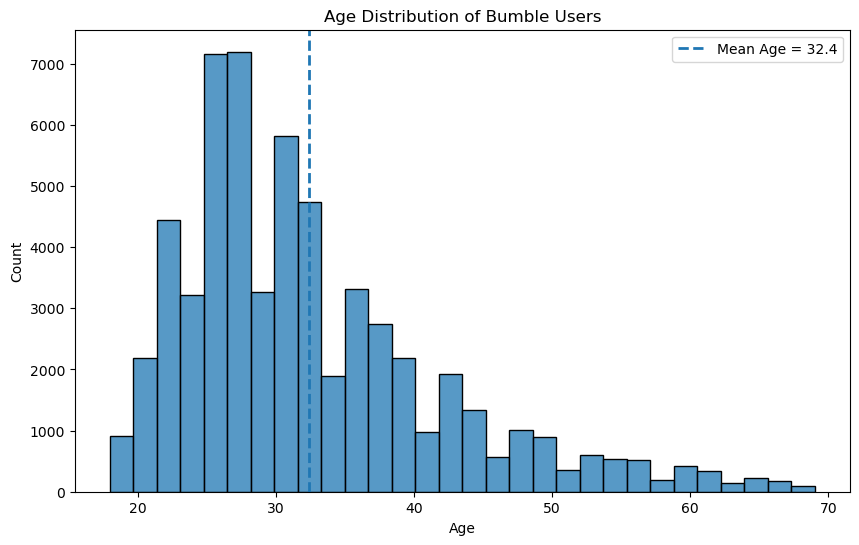

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

mean_age = df_clean['age'].mean() # calculates the average age.

plt.figure(figsize=(10,6))
sns.histplot(data=df_clean, x='age', bins=30, kde=False) # makes the histogram easier to read.
plt.axvline(mean_age, linestyle='--', linewidth=2, label=f'Mean Age = {mean_age:.1f}')  # adds the required vertical line.

plt.title('Age Distribution of Bumble Users')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

#### The histogram indicates that the majority of users fall between 25 and 30 years, which represents the highest density of observations. Although the mean age is 32.4, the peak of the distribution lies below the mean, confirming that younger users dominate the platform.

### (2) How does the age distribution differ by gender? Are there age groups where one gender is more prevalent?

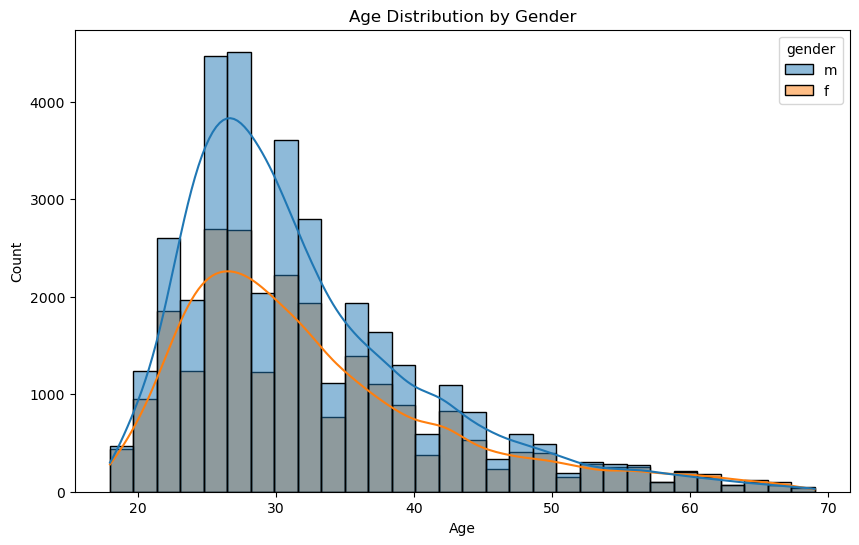

In [72]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean, x='age', hue='gender', bins=30, kde=True)

plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#### Yes, there are slight differences between genders across age groups. Males are more prevalent in the younger age range (around 23–30), where the histogram bars and density curve for males are higher than females. In contrast, females are more evenly distributed and show relatively stronger presence in the 30–40 age range, although the difference is not very large. Overall, both genders overlap heavily in the 25–35 range, which is the most active age group on the platform.


#### The ash (grey) color appears because the male (blue) and female (orange) bars are plotted on top of each other. When both genders have users in the same age range, the colors overlap and visually blend into grey. This actually indicates that both genders are present in that age group.



## 2. Income and Age

### (1) Use a scatterplot to visualize the relationship between income and age, with a trend line indicating overall patterns. Are older users more likely to report higher incomes?

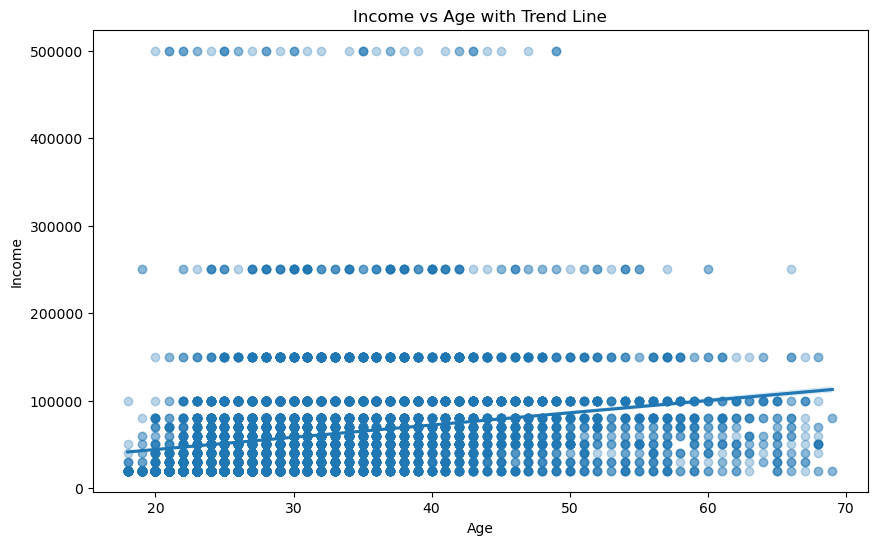

In [73]:
plt.figure(figsize=(10,6))
sns.regplot(data=df_clean, x='age', y='income', scatter_kws={'alpha':0.3}) # regplot (it adds a trend line automatically)

plt.title("Income vs Age with Trend Line")
plt.xlabel("Age")
plt.ylabel("Income")

plt.show()

#### While the trend line suggests that older users tend to report higher incomes, the relationship is weak and inconsistent. Income values are highly clustered across all age groups, and even younger users appear in similar income brackets. This indicates that age alone is not a strong predictor of income in this dataset.

### (2) Create boxplots of income grouped by age_group. Which age group reports the highest median income?

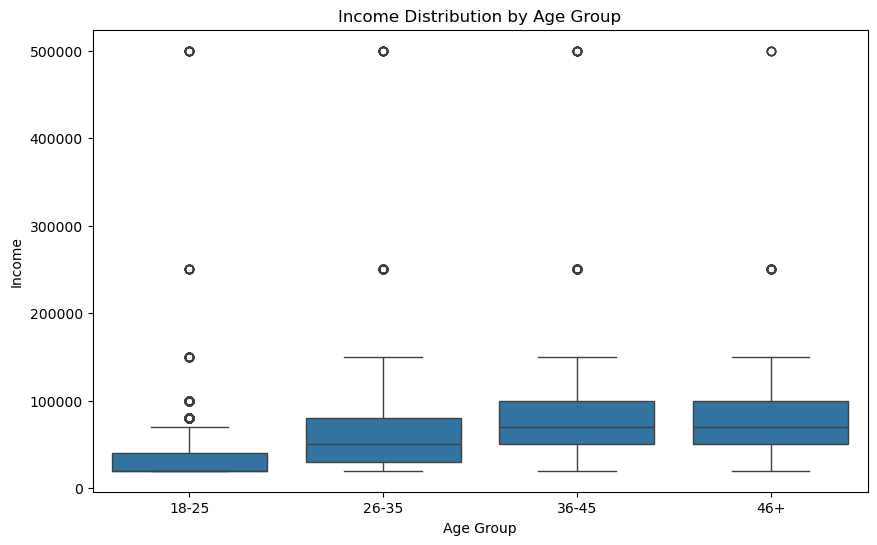

In [74]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='age_group', y='income')

plt.title("Income Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Income")

plt.show()

#### The 500,000 income values were retained because they appear to be valid observations rather than errors. Most individuals reporting this income belong to high-paying professions such as professors and doctors, with only a few inconsistent cases. Since these values account for only about 0.45% of the dataset (48 out of 10,500 records), they are considered negligible in terms of impact. Therefore, they were kept as legitimate outliers and interpreted cautiously during analysis.

### (3) Analyze income levels within gender and status categories. For example, are single men more likely to report higher incomes than single women?

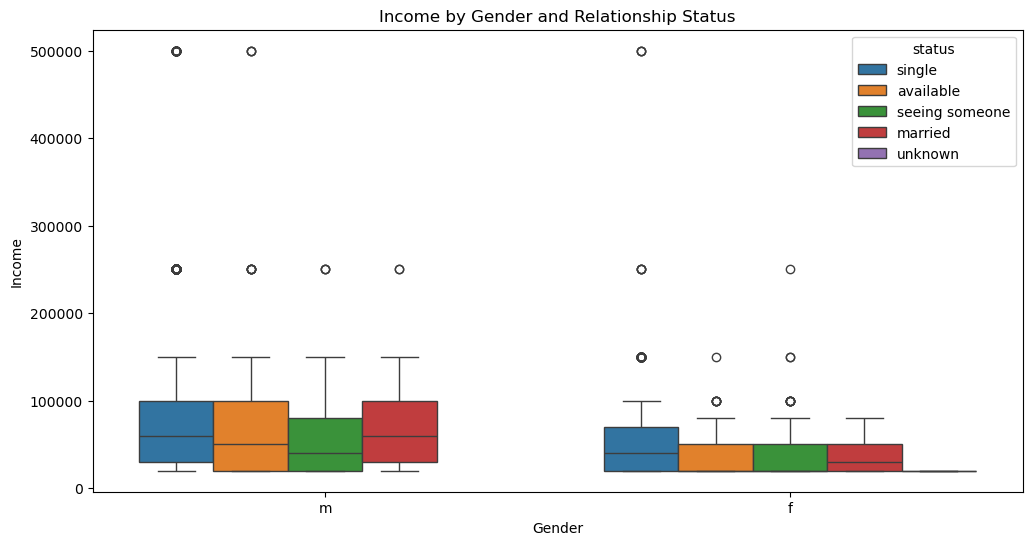

In [75]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='gender', y='income', hue='status') 

# using boxplot rather than scatter plot because; scatter works for numerical vs numerical

plt.title("Income by Gender and Relationship Status")
plt.xlabel("Gender")
plt.ylabel("Income")

plt.show()

#### The boxplot shows that across all relationship statuses, males tend to have higher median incomes than females. For example, among single users, the median income for men is approximately $55k–$60k, while for women it is around $35k–$40k. A similar pattern is observed for other statuses such as “available” and “married.” Despite this difference, there is considerable overlap in income distributions, and extreme values (up to $500k) appear in both genders but act as outliers.

## 3. Pets and Preferences

### (1) Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?

#### Pet Preferences Analysis – Data Transformation and Feature Engineering

#### 1. Problem with the Original Data

#### The `pets` column contains text-based, multi-label data such as:

#### - "likes dogs"  
#### - "likes cats"  
#### - "likes dogs and likes cats"  
#### - "has dogs"  
#### - "dislikes cats"  

#### This creates issues:
#### - Multiple categories are combined in one column
#### - Difficult to count or analyze individual preferences
#### - Not suitable for direct visualization


#### 2. Handling Missing Values

#### Missing values (`NaN`) are replaced with `"unknown"` to retain all records and avoid incorrect assumptions.

In [76]:
# Step 1: Inspect values

df_clean['pets'].unique()

array(['likes dogs and likes cats', 'has cats', 'likes cats', nan,
       'has dogs and likes cats', 'likes dogs and has cats',
       'likes dogs and dislikes cats', 'has dogs',
       'has dogs and dislikes cats', 'likes dogs',
       'has dogs and has cats', 'dislikes dogs and has cats',
       'dislikes dogs and dislikes cats', 'dislikes cats',
       'dislikes dogs and likes cats', 'dislikes dogs'], dtype=object)

In [77]:
# Step 2: Fill missing values

df_clean['pets'] = df_clean['pets'].fillna('unknown')

df_clean['pets'].isnull().sum()

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\1010789087.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['pets'] = df_clean['pets'].fillna('unknown')


np.int64(0)

#### 3. Creating Binary Preference Columns

#### To simplify analysis, we convert text data into binary variables:

#### - `likes_dogs` → 1 if user likes dogs, else 0  
#### - `likes_cats` → 1 if user likes cats, else 0  

#### This allows easier counting and visualization.

In [78]:
# Step 3: Check top raw categories

df_clean['pets'].value_counts()

pets
unknown                            19797
likes dogs and likes cats          14624
likes dogs                          7160
likes dogs and has cats             4274
has dogs                            4091
has dogs and likes cats             2306
likes dogs and dislikes cats        2010
has dogs and has cats               1453
has cats                            1395
likes cats                          1060
has dogs and dislikes cats           544
dislikes dogs and likes cats         235
dislikes dogs and dislikes cats      189
dislikes cats                        120
dislikes dogs and has cats            79
dislikes dogs                         44
Name: count, dtype: int64

#### Understanding the Transformation

Each row is checked:

- If "likes dogs" is present → 1  
- Otherwise → 0  

Example:

| pets                         | likes_dogs | likes_cats |
|------------------------------|-----------|-----------|
| likes dogs                  | 1         | 0         |
| likes cats                  | 0         | 1         |
| likes dogs and likes cats   | 1         | 1         |
| has dogs                    | 0         | 0 |

In [79]:
# Step 4: Create binary preference columns

df_clean['likes_dogs'] = df_clean['pets'].str.contains('likes dogs', na=False).astype(int)

df_clean['likes_cats'] = df_clean['pets'].str.contains('likes cats', na=False).astype(int)

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3822355036.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['likes_dogs'] = df_clean['pets'].str.contains('likes dogs', na=False).astype(int)
C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\3822355036.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['likes_cats'] = df_clean['pets'].str.contains('likes cats', na=False).astype(int)


In [80]:
# Step 5: Count users

dogs_count = df_clean['likes_dogs'].sum()

cats_count = df_clean['likes_cats'].sum()

print("Likes Dogs:", dogs_count)
print("Likes Cats:", cats_count)

Likes Dogs: 28615
Likes Cats: 21088


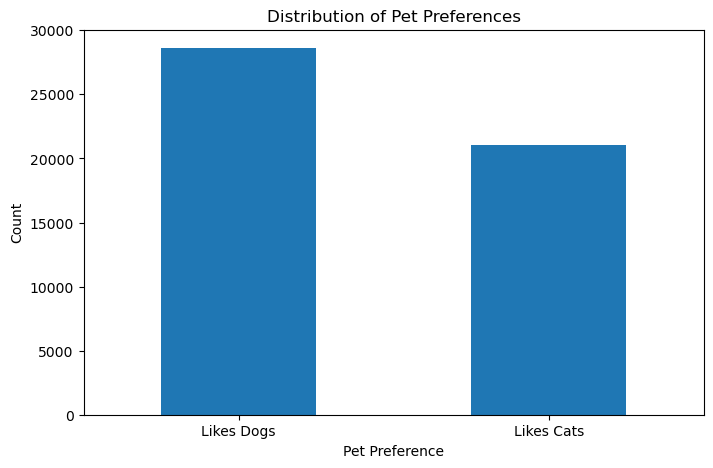

In [81]:
# Step 6

import matplotlib.pyplot as plt
import pandas as pd

pet_preferences = pd.Series({
    'Likes Dogs': dogs_count,
    'Likes Cats': cats_count
})

plt.figure(figsize=(8,5))
pet_preferences.plot(kind='bar')

plt.title('Distribution of Pet Preferences')
plt.xlabel('Pet Preference')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

#### The analysis shows that dogs are significantly more popular than cats on the platform, with approximately 28.6k users expressing a preference for dogs compared to 21.1k for cats. However, since users can like both dogs and cats, these categories are not mutually exclusive, indicating that while dogs are more popular overall, many users are open to both pets.

### (2) How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?

In [82]:
# Step 1: Create a combined “likes pets” column

df_clean['likes_pets'] = ((df_clean['likes_dogs'] == 1) | (df_clean['likes_cats'] == 1)).astype(int)

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\349590188.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['likes_pets'] = ((df_clean['likes_dogs'] == 1) | (df_clean['likes_cats'] == 1)).astype(int)


In [83]:
# Step 2: Pets vs Gender

pets_gender = df_clean.groupby('gender')['likes_pets'].mean()*100
pets_gender

gender
f    56.160327
m    54.173139
Name: likes_pets, dtype: float64

In [84]:
# Step 3: Pets vs Age Group

pets_age = df_clean.groupby('age_group')['likes_pets'].mean()*100
pets_age

age_group
18-25    53.534077
26-35    56.102293
36-45    55.392066
46+      52.348660
Name: likes_pets, dtype: float64

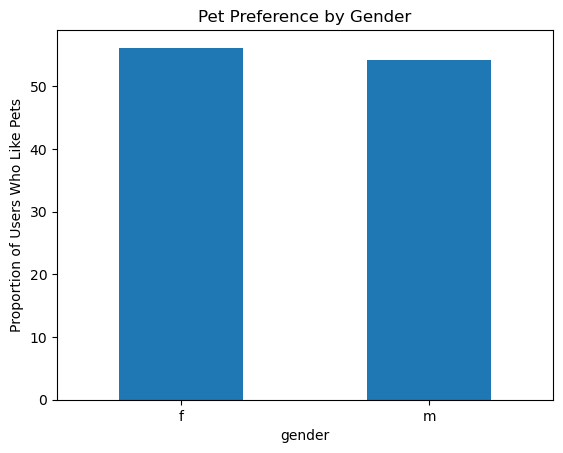

In [85]:
# Step 4: Visualization - Gender comparison

pets_gender.plot(kind='bar')

plt.title("Pet Preference by Gender")
plt.ylabel("Proportion of Users Who Like Pets")
plt.xticks(rotation=0)

plt.show()

#### Pet Preference by Gender

#### Pet preference is very similar across genders, with approximately 56% of females and 54% of males reporting that they like pets. This indicates that there is no significant gender difference in pet preference, although females show a slightly higher inclination.

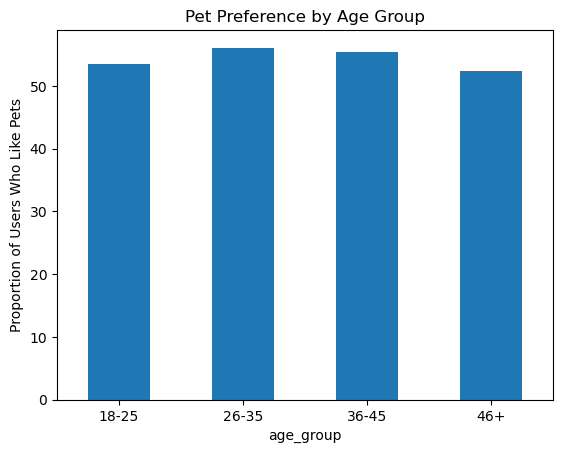

In [86]:
# Step 4: Visualization - Age group comparison

pets_age.plot(kind='bar')

plt.title("Pet Preference by Age Group")
plt.ylabel("Proportion of Users Who Like Pets")
plt.xticks(rotation=0)

plt.show()

#### Pet Preference by Age Group

#### Pet preference is relatively consistent across age groups, with a slight peak in the 26–35 (≈56%) and 36–45 (≈55%) groups. Younger users (18–25) show slightly lower preference (54%), while the 46+ group has the lowest (52–53%), indicating a small decline in pet preference with age.

## 4. Signs and Personality

### (1) Create a pie chart showing the distribution of zodiac signs (sign) across the platform. Which signs are most and least represented? Is this the right chart? If not, replace with right chart.

In [87]:
df_clean.sign.unique()

array(['gemini', 'cancer', 'pisces but it doesn&rsquo;t matter', 'pisces',
       'aquarius', 'taurus', 'virgo', 'sagittarius',
       'gemini but it doesn&rsquo;t matter',
       'cancer but it doesn&rsquo;t matter',
       'leo but it doesn&rsquo;t matter', nan,
       'aquarius but it doesn&rsquo;t matter',
       'aries and it&rsquo;s fun to think about',
       'libra but it doesn&rsquo;t matter',
       'pisces and it&rsquo;s fun to think about', 'libra',
       'taurus but it doesn&rsquo;t matter',
       'sagittarius but it doesn&rsquo;t matter',
       'scorpio and it matters a lot',
       'gemini and it&rsquo;s fun to think about',
       'leo and it&rsquo;s fun to think about',
       'cancer and it&rsquo;s fun to think about',
       'libra and it&rsquo;s fun to think about',
       'aquarius and it&rsquo;s fun to think about',
       'virgo but it doesn&rsquo;t matter',
       'scorpio and it&rsquo;s fun to think about',
       'capricorn but it doesn&rsquo;t matter', 'sc

In [88]:
# First: Is pie chart correct?

# No, pie chart is NOT the best choice

# Why:

# Too many categories (12 signs)
# Hard to compare slices
# Not readable

# Best chart: Bar chart (sorted)

#Much clearer:

# Easy to compare counts
# Easy to identify most/least common

In [89]:
# Step 1: Clean the sign column

df_clean['sign_clean'] = df_clean['sign'].str.lower().str.extract(
    r'(aries|taurus|gemini|cancer|leo|virgo|libra|scorpio|sagittarius|capricorn|aquarius|pisces)'
)

df_clean['sign_clean']

C:\Users\aksha\AppData\Local\Temp\ipykernel_3928\147638774.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['sign_clean'] = df_clean['sign'].str.lower().str.extract(


0             gemini
1             cancer
2             pisces
3             pisces
4           aquarius
            ...     
59941         cancer
59942            leo
59943    sagittarius
59944            leo
59945         gemini
Name: sign_clean, Length: 59381, dtype: object

In [90]:
# Step 2: Check cleaned values

df_clean['sign_clean'].value_counts()

sign_clean
leo            4327
gemini         4272
libra          4166
cancer         4156
virgo          4110
taurus         4096
scorpio        4085
aries          3955
pisces         3914
sagittarius    3902
aquarius       3898
capricorn      3544
Name: count, dtype: int64

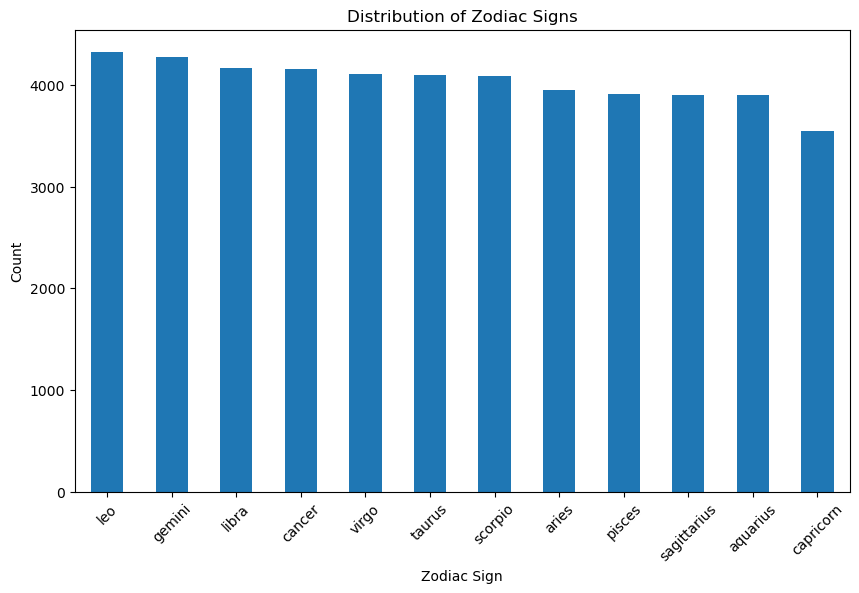

In [91]:
# Step 3: Plot bar chart

import matplotlib.pyplot as plt

sign_counts = df_clean['sign_clean'].value_counts()

plt.figure(figsize=(10,6))
sign_counts.plot(kind='bar')

plt.title("Distribution of Zodiac Signs")
plt.xlabel("Zodiac Sign")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

#### The distribution of zodiac signs on the platform is fairly balanced, with no single sign overwhelmingly dominating the user base. Leo appears to be the most represented sign, with roughly 4.3k users, while Capricorn is the least represented, with around 3.6k users. The gap between the highest and lowest categories is relatively small, which suggests that zodiac signs are broadly well distributed across Bumble users rather than concentrated in a few signs.

### (2) How does sign vary across gender and status? Are there noticeable patterns or imbalances?

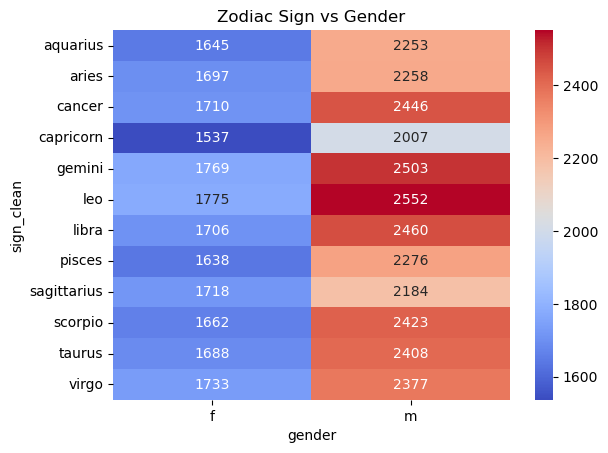

In [92]:
# Heatmap for gender

sign_gender = pd.crosstab(df_clean['sign_clean'], df_clean['gender'])

sns.heatmap(sign_gender, cmap='coolwarm', annot=True, fmt='d')

plt.title("Zodiac Sign vs Gender")
plt.show()

#### Heatmap 1: Zodiac Sign vs Gender

#### What it shows:
#### For every zodiac sign, the number of males is consistently higher than females

#### Example:

#### Leo → ~2550 males vs ~1775 females
#### Gemini → ~2500 males vs ~1770 females
#### Capricorn (lowest) → still more males (2000) than females (1500)

#### Noticeable Pattern:

#### While male users outnumber female users across all zodiac signs, the relative distribution of signs remains consistent between genders. This suggests that zodiac sign is not a differentiating factor between male and female users on the platform, and the observed differences are primarily driven by overall gender composition.

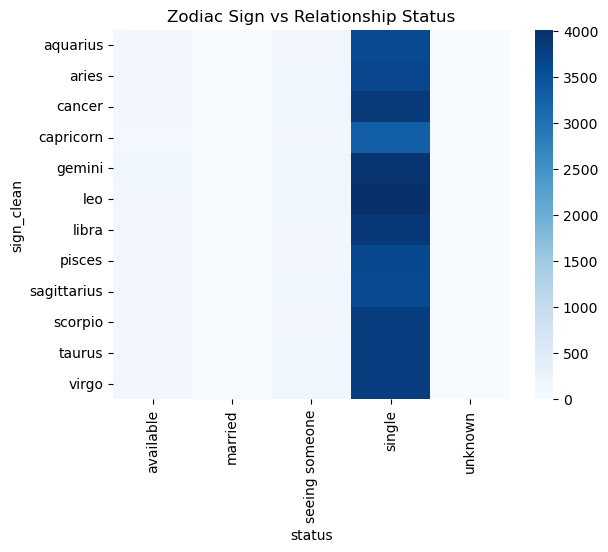

In [93]:
# heatmap for status

sign_status = pd.crosstab(df_clean['sign_clean'], df_clean['status'])

sns.heatmap(sign_status, cmap='Blues')

plt.title("Zodiac Sign vs Relationship Status")
plt.show()

#### Heatmap 2: Zodiac Sign vs Relationship Status

#### What it shows:
#### The “single” category dominates heavily for all zodiac signs

#### Other categories:
#### “available”, “seeing someone”, “married”, “unknown”
#### → all much lower and fairly similar across signs

#### Example:
#### Leo, Gemini, Cancer → highest counts in “single”
#### Capricorn → slightly lower but still follows same pattern

#### Noticeable Pattern:

#### The distribution of relationship status is heavily skewed toward “single” users across all zodiac signs, which aligns with the platform’s primary use case. Importantly, this pattern is consistent across all signs, suggesting that zodiac sign does not influence relationship status distribution among users.